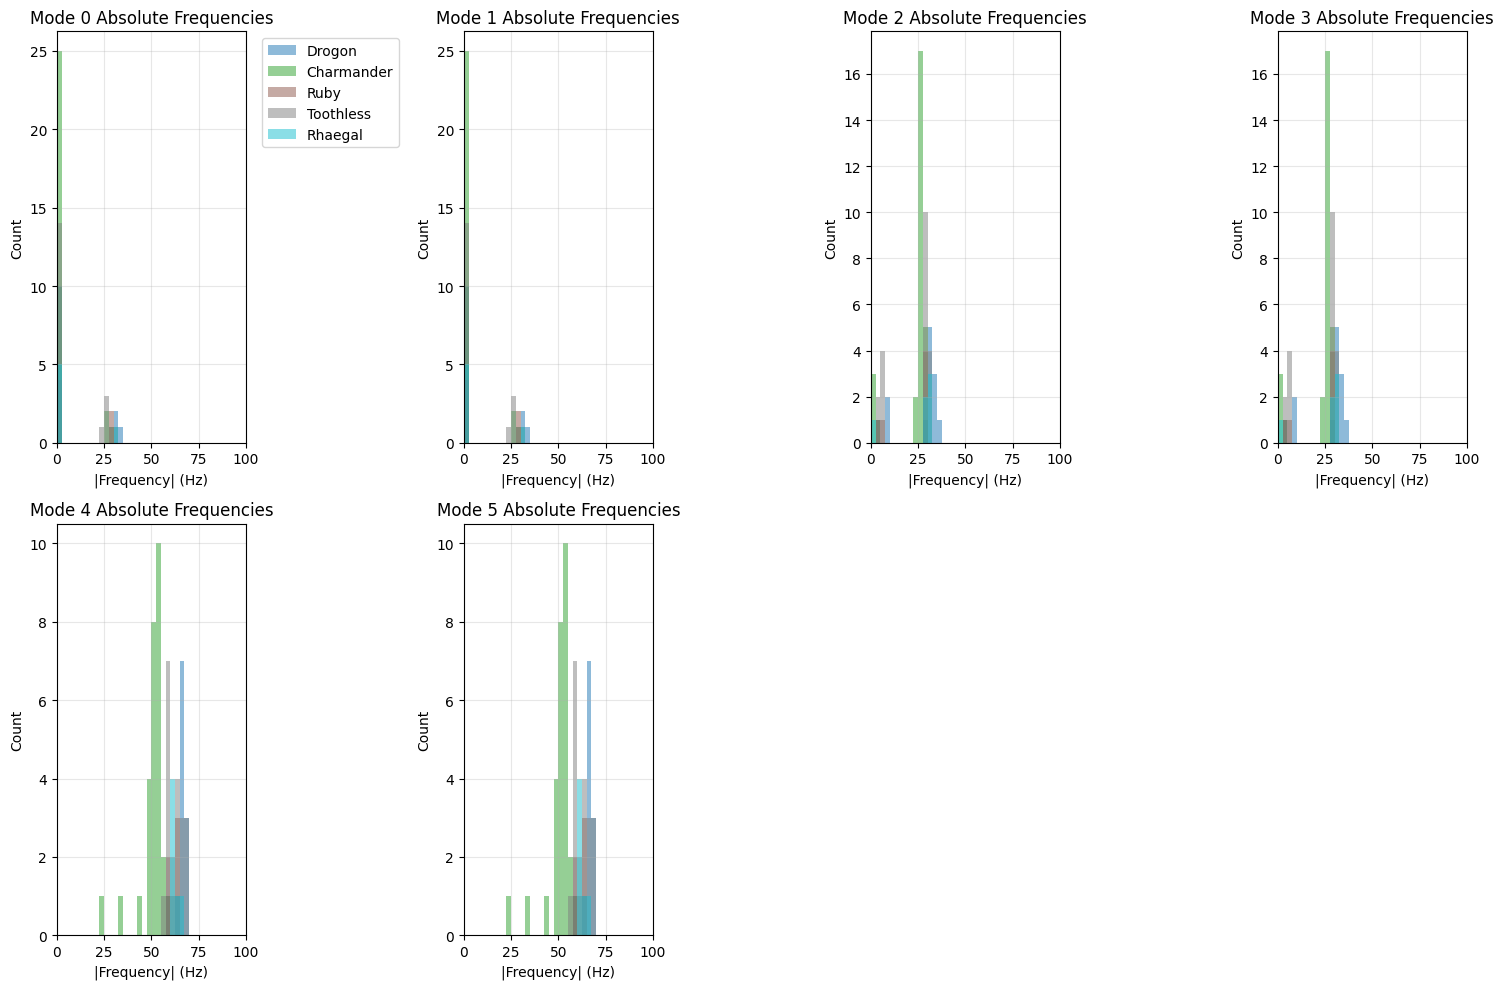


Mode 0 absolute frequency statistics by bird:

Drogon:
count    13.000
mean      7.646
std      14.115
min       0.000
25%       0.000
50%       0.000
75%       2.280
max      33.872
Name: mode_0_freq, dtype: float64

Charmander:
count    28.000
mean      2.981
std       8.438
min       0.000
25%       0.000
50%       0.000
75%       0.017
max      28.371
Name: mode_0_freq, dtype: float64

Ruby:
count     6.000
mean      9.628
std      14.442
min       0.000
25%       0.000
50%       0.624
75%      21.253
max      28.599
Name: mode_0_freq, dtype: float64

Toothless:
count    20.000
mean      8.198
std      12.929
min       0.000
25%       0.000
50%       0.000
75%      24.918
max      32.267
Name: mode_0_freq, dtype: float64

Rhaegal:
count     6.000
mean      5.007
std      12.261
min       0.000
25%       0.000
50%       0.000
75%       0.004
max      30.034
Name: mode_0_freq, dtype: float64

Mode 1 absolute frequency statistics by bird:

Drogon:
count    13.000
mean      7.646
std 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the results
results_df = pd.read_csv('../data/dmd_batch_results.csv')

# Set up the plot
plt.figure(figsize=(15, 10))
n_modes = 6

# Customize these parameters
bins = 40
freq_max = 100  # Maximum absolute frequency to show

# Get unique bird names and assign colors
bird_names = results_df['bird_name'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(bird_names)))  # Distinct colors for each bird

# Create subplots for each mode
for i in range(n_modes):
    plt.subplot(2, 4, i+1)
    
    # Plot histogram for each bird
    for bird, color in zip(bird_names, colors):
        bird_data = results_df[results_df['bird_name'] == bird]
        
        # Take absolute value of frequencies
        freqs = np.abs(bird_data[f'mode_{i}_freq'])
        
        plt.hist(freqs, 
                 bins=bins,
                 range=(0, freq_max),  # Start from 0 for absolute frequencies
                 alpha=0.5,
                 label=bird,
                 color=color)
    
    plt.title(f'Mode {i} Absolute Frequencies')
    plt.xlabel('|Frequency| (Hz)')
    plt.ylabel('Count')
    
    # Customize axis limits
    plt.xlim(0, freq_max)
    
    # Add grid if desired
    plt.grid(True, alpha=0.3)
    
    # Add legend if it's the first subplot
    if i == 0:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Print summary statistics by bird for each mode
for i in range(n_modes):
    print(f"\nMode {i} absolute frequency statistics by bird:")
    for bird in bird_names:
        bird_data = results_df[results_df['bird_name'] == bird]
        freqs = np.abs(bird_data[f'mode_{i}_freq'])
        print(f"\n{bird}:")
        print(freqs.describe().round(3))